# XGBoost — Quarterly Rolling 2-Year Window (5-Day Gap)

**Model**: XGBoost multiclass signal detector  
**Target**: `target_excess_xfn_5d` (TD vs XFN 5-day excess return)  
**Features**: 15 simple/explainable features  
**Cadence**: Quarterly (~63 trading days per test fold)  
**Window**: Rolling 2 years (~504 trading days)  
**Gap**: 5 trading days between `train_end` and `test_start` (target leakage prevention)

### Grid Design Rationale
Each training fold has **~504 rows** and **15 features** (3-class problem → ~168 rows/class).

| Parameter | Range | Reasoning |
|---|---|---|
| `max_depth` | 2, 3, 4 | Depth 6 → up to 64 leaves on 504 rows (~8 rows/leaf). Shallow trees safer. |
| `min_child_weight` | 10, 20, 40 | 2–8% of rows per leaf minimum (was 1–10, too permissive). |
| `n_estimators` | 80, 150, 250 | Moderate counts; regularization controls overfitting rather than early stopping. |
| `reg_alpha` (L1) | 0.0, 1.0, 2.0 | **Searched**: L1 prunes weak features on a small dataset. |
| `reg_lambda` (L2) | 1.0, 5.0, 10.0 | **Searched**: stronger L2 needed when few rows per leaf. |
| `subsample` | 0.8 | Fixed (row sampling; stable at 0.8 for this dataset size). |
| `colsample_bytree` | 0.8 | Fixed (12/15 features per tree; randomises without over-thinning). |
| `learning_rate` | 0.05 | Fixed (conservative; lets n_estimators control capacity). |

**Grid size**: 3 × 3 × 3 × 3 × 3 = **243 configs × 7 tuning folds**

In [1]:
import sys
import warnings
import pickle
import json
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.metrics import f1_score
from IPython.display import display

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[2]
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments_archive'
for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'ROOT: {ROOT}')

ROOT: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis


In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import STRIDE_EVAL

df = load_dataset()

def call_decay_from_days(days, halflife=20.0):
    return np.exp(-days.clip(lower=0).fillna(999.0) / halflife)

call_decay = call_decay_from_days(df['days_since_call'])
df['evt_exec_tone']         = df[['transcript_ceo_prep_sentiment_mean_ffill',
                                   'transcript_cfo_prep_sentiment_mean_ffill']].mean(axis=1) * call_decay
df['evt_guidance_topic']     = df['topic_guidance_share_ffill'] * call_decay
df['evt_guidance_sentiment'] = df['topic_guidance_sentiment_ffill'] * call_decay
df['evt_aml_topic']          = df['topic_regulatory_AML_share_ffill'] * call_decay
df['evt_aml_sentiment']      = df['topic_regulatory_AML_sentiment_ffill'] * call_decay

FEATURES = [
    'td_return_5d', 'td_return_20d', 'td_vs_xfn_5d', 'td_dist_52w_high',
    'news_sent_mean_30d', 'news_count_30d', 'days_since_last_news',
    'days_since_call', 'is_earnings_week',
    'evt_exec_tone', 'evt_framing_gap',
    'evt_guidance_topic', 'evt_guidance_sentiment',
    'evt_aml_topic', 'evt_aml_sentiment',
]
TARGET            = 'target_excess_xfn_5d'
THRESHOLD         = 0.003
LABEL_MAP         = {-1: 0, 0: 1, 1: 2}
INV_MAP           = {0: -1, 1: 0, 2: 1}
STRIDE            = STRIDE_EVAL
TRAIN_WINDOW_DAYS = 504   # ~2 years of trading days
QUARTER_DAYS      = 63    # ~1 quarter
GAP_DAYS          = 5     # leakage prevention: 5-day forward return target

missing = [f for f in FEATURES if f not in df.columns]
assert not missing, f'Missing: {missing}'
print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Training window : {TRAIN_WINDOW_DAYS} td (~2 years, rolling)')
print(f'Gap             : {GAP_DAYS} td between train_end and test_start')
print(f'Features        : {len(FEATURES)}')

Loaded 1285 rows  |  2021-02-25 to 2026-04-09
Training window : 504 td (~2 years, rolling)
Gap             : 5 td between train_end and test_start
Features        : 15


## 1. Define Quarterly Rolling 2-Year Folds

In [3]:
def make_quarterly_rolling2y_folds(df, target,
                                   train_days=TRAIN_WINDOW_DAYS,
                                   quarter_days=QUARTER_DAYS,
                                   gap=GAP_DAYS):
    dated = df[df[target].notna()].sort_values('date')
    dates = dated['date'].values
    folds = []
    i, fold_id = train_days + gap, 1
    while i < len(dates):
        te_end_i      = min(i + quarter_days - 1, len(dates) - 1)
        train_end_idx = i - 1 - gap
        tr_s_i        = max(0, train_end_idx + 1 - train_days)
        folds.append((
            fold_id,
            str(dates[tr_s_i])[:10],
            str(dates[train_end_idx])[:10],
            str(dates[i])[:10],
            str(dates[te_end_i])[:10],
        ))
        i = te_end_i + 1
        fold_id += 1
    return folds

FOLDS = make_quarterly_rolling2y_folds(df, TARGET)

print(f'Total quarterly folds: {len(FOLDS)}')
print(f'{"Fold":<6} {"Train start":<13} {"Train end":<13} '
      f'{"Test start":<13} {"Test end":<13} {"Gap(cal)":>9} {"Train n":>8} {"Test n":>7}')
print('-' * 82)
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    tr = df[(df['date'] >= pd.Timestamp(tr_s)) &
            (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    te = df[(df['date'] >= pd.Timestamp(te_s)) &
            (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    gap_cal = (pd.Timestamp(te_s) - pd.Timestamp(tr_e)).days
    print(f'{fold_id:<6} {tr_s:<13} {tr_e:<13} {te_s:<13} {te_e:<13} '
          f'{gap_cal:>9} {len(tr):>8} {len(te):>7}')

# Describe training set sizes to inform grid design
sizes = []
for _, tr_s, tr_e, te_s, te_e in FOLDS:
    tr = df[(df['date'] >= pd.Timestamp(tr_s)) &
            (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    sizes.append(len(tr))
print(f'\nTraining set size: min={min(sizes)}  max={max(sizes)}  mean={np.mean(sizes):.0f}')
print(f'Features per fold: {len(FEATURES)}')
print(f'Rows/feature ratio: {np.mean(sizes)/len(FEATURES):.1f}  '
      f'(< 30 suggests strong regularization needed)')

Total quarterly folds: 13
Fold   Train start   Train end     Test start    Test end       Gap(cal)  Train n  Test n
----------------------------------------------------------------------------------
1      2021-02-25    2023-02-28    2023-03-08    2023-06-06            8      504      63
2      2021-05-27    2023-05-30    2023-06-07    2023-09-06            8      504      63
3      2021-08-26    2023-08-29    2023-09-07    2023-12-05            9      504      63
4      2021-11-25    2023-11-28    2023-12-06    2024-03-07            8      504      63
5      2022-02-28    2024-02-29    2024-03-08    2024-06-06            8      504      63
6      2022-05-30    2024-05-30    2024-06-07    2024-09-06            8      504      63
7      2022-08-29    2024-08-29    2024-09-09    2024-12-05           11      504      63
8      2022-11-28    2024-11-28    2024-12-06    2025-03-10            8      504      63
9      2023-03-01    2025-03-03    2025-03-11    2025-06-09            8      504

## 2. Helper Functions

In [4]:
def fit_xgb(train_df, test_df, params):
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([LABEL_MAP[v] for v in y_tr], dtype=int)
    clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3,
                            random_state=42, n_jobs=1, verbosity=0, **params)
    clf.fit(x_tr, y_enc)
    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds     = np.array([INV_MAP[int(p)] for p in clf.predict(x_te)])
    return clf, preds, y_te_cls, y_te_cont

def offset_metrics(preds, y_true_cls, y_true_cont):
    rows = []
    for off in range(STRIDE):
        idx = np.arange(off, len(preds), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows).mean()

print('Helper functions defined.')

Helper functions defined.


## 3. Hyperparameter Grid Search

Grid is calibrated for ~504 training rows and 15 features:
- **max_depth [2, 3, 4]**: depth 6 → ≤8 rows/leaf on 504 rows; depth 2–4 is safer
- **min_child_weight [10, 20, 40]**: 2–8% of rows as minimum leaf weight (old: 1–10, too loose)
- **n_estimators [80, 150, 250]**: capacity controlled by regularization rather than early stopping
- **reg_alpha [0.0, 1.0, 2.0]**: L1 searched — sparse selection helpful on 15 features with small n
- **reg_lambda [1.0, 5.0, 10.0]**: L2 searched — stronger shrinkage stabilizes shallow trees on small data

Total: **3 × 3 × 3 × 3 × 3 = 243 configs** evaluated on middle folds.

In [5]:
n_folds    = len(FOLDS)
tune_start = max(2, n_folds // 4)
tune_end   = min(n_folds - 2, n_folds * 3 // 4)
TUNE_FOLDS = FOLDS[tune_start : tune_end + 1]
print(f'Tuning on folds {tune_start+1}..{tune_end+1} ({len(TUNE_FOLDS)} of {n_folds} total)')

# Data-aware grid
GRID = {
    'max_depth':        [2, 3, 4],        # shallow trees for ~500 rows
    'min_child_weight': [10, 20, 40],     # 2–8% of rows per leaf
    'n_estimators':     [80, 150, 250],   # capacity range
    'reg_alpha':        [0.0, 1.0, 2.0],  # L1: feature sparsity
    'reg_lambda':       [1.0, 5.0, 10.0], # L2: weight shrinkage
    # Fixed — stable at these values for this dataset:
    'learning_rate':    [0.05],
    'subsample':        [0.8],
    'colsample_bytree': [0.8],
    'tree_method':      ['hist'],
}

from itertools import product as iproduct
param_combos = list(iproduct(
    GRID['max_depth'], GRID['min_child_weight'], GRID['n_estimators'],
    GRID['reg_alpha'], GRID['reg_lambda'],
))
print(f'Grid: {len(param_combos)} configs x {len(TUNE_FOLDS)} tuning folds = {len(param_combos)*len(TUNE_FOLDS)} fits')

search_rows = []
for md, mcw, ne, ra, rl in param_combos:
    params = dict(
        max_depth=md, min_child_weight=mcw, n_estimators=ne,
        reg_alpha=ra, reg_lambda=rl,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    )
    fold_metrics = []
    for fold_id, tr_s, tr_e, te_s, te_e in TUNE_FOLDS:
        train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                      (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
        test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                      (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
        if len(test_df) < 10:
            continue
        _, preds, y_cls, y_cont = fit_xgb(train_df, test_df, params)
        fold_metrics.append(offset_metrics(preds, y_cls, y_cont))
    if not fold_metrics:
        continue
    agg = pd.DataFrame(fold_metrics).mean()
    search_rows.append({
        'max_depth': md, 'min_child_weight': mcw, 'n_estimators': ne,
        'reg_alpha': ra, 'reg_lambda': rl,
        'active_asa': agg['active_asa'], 'macro_f1': agg['macro_f1'],
        'active_cov': agg['active_cov'],
        'composite': 0.6 * agg['active_asa'] + 0.4 * agg['macro_f1'],
    })

search_df = pd.DataFrame(search_rows).sort_values('composite', ascending=False)
best_row  = search_df.iloc[0]

BEST_PARAMS = dict(
    max_depth=int(best_row.max_depth),
    min_child_weight=int(best_row.min_child_weight),
    n_estimators=int(best_row.n_estimators),
    reg_alpha=float(best_row.reg_alpha),
    reg_lambda=float(best_row.reg_lambda),
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, tree_method='hist',
)

print('=== Top-10 configs ===')
display(search_df.head(10).round(4))
print(f'\nBest params : {BEST_PARAMS}')
print(f'Composite   : {best_row.composite:.4f}')

Tuning on folds 4..10 (7 of 13 total)
Grid: 243 configs x 7 tuning folds = 1701 fits


=== Top-10 configs ===


,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,active_asa,macro_f1,active_cov,composite
89,3,10,80,2.0,10.0,0.5458,0.3091,1.0000,0.4511
116,3,20,80,2.0,10.0,0.5425,0.3087,1.0000,0.4490
86,3,10,80,1.0,10.0,0.5375,0.3112,0.9978,0.4470
108,3,20,80,0.0,1.0,0.5383,0.3049,0.9888,0.4450
115,3,20,80,2.0,5.0,0.5376,0.3037,0.9976,0.4440
88,3,10,80,2.0,5.0,0.5380,0.3022,0.9932,0.4436
85,3,10,80,1.0,5.0,0.5335,0.3074,0.9932,0.4431
97,3,10,150,2.0,5.0,0.5368,0.3021,0.9769,0.4429
168,4,10,80,2.0,1.0,0.5324,0.3082,0.9815,0.4427
4,2,10,80,1.0,5.0,0.5396,0.2969,0.9932,0.4425



Best params : {'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 80, 'reg_alpha': 2.0, 'reg_lambda': 10.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'}
Composite   : 0.4511


## 3b. Regularization Effect — Diagnostic Plots

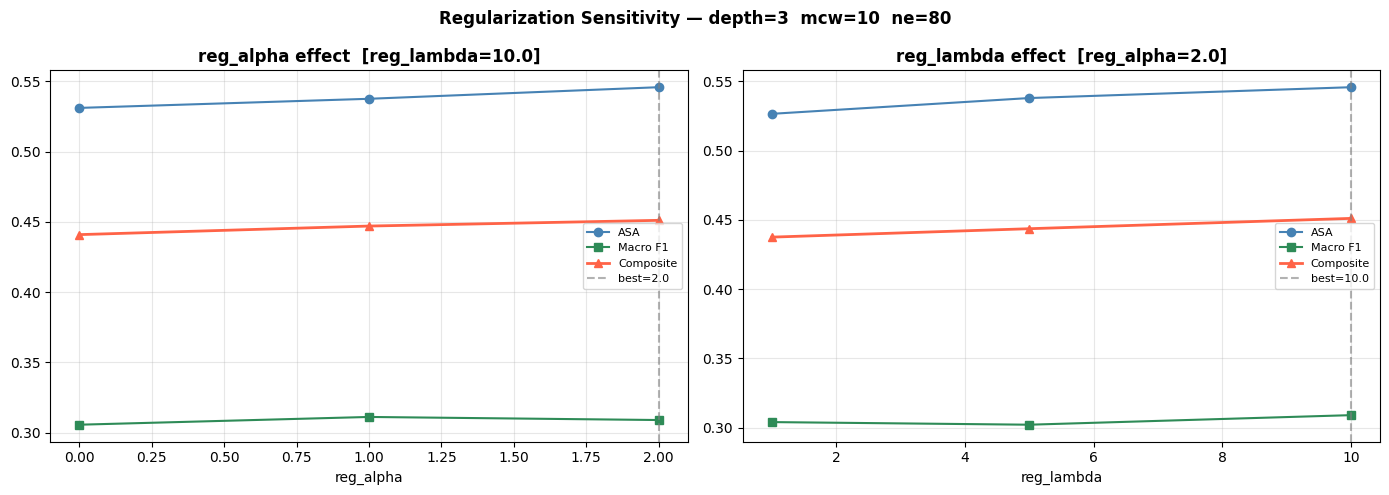

In [6]:
# Show how L1/L2 interact with the best architecture
best_arch = search_df[(search_df.max_depth == best_row.max_depth) &
                      (search_df.min_child_weight == best_row.min_child_weight) &
                      (search_df.n_estimators == best_row.n_estimators)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, reg_var, fixed_var, fixed_val in [
    (axes[0], 'reg_alpha', 'reg_lambda', best_row.reg_lambda),
    (axes[1], 'reg_lambda', 'reg_alpha', best_row.reg_alpha),
]:
    sub = best_arch[best_arch[fixed_var] == fixed_val].sort_values(reg_var)
    ax.plot(sub[reg_var], sub['active_asa'],  marker='o', label='ASA',      color='steelblue')
    ax.plot(sub[reg_var], sub['macro_f1'],    marker='s', label='Macro F1', color='seagreen')
    ax.plot(sub[reg_var], sub['composite'],   marker='^', label='Composite',color='tomato', linewidth=2)
    ax.axvline(best_row[reg_var], color='gray', linestyle='--', alpha=0.6, label=f'best={best_row[reg_var]}')
    ax.set_xlabel(reg_var, fontsize=10)
    ax.set_title(f'{reg_var} effect  [{fixed_var}={fixed_val}]', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    f'Regularization Sensitivity — depth={int(best_row.max_depth)}  '
    f'mcw={int(best_row.min_child_weight)}  ne={int(best_row.n_estimators)}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(); plt.show()

## 4. Full Walk-Forward Evaluation

In [7]:
fold_results       = []
fold_models        = []
fold_x_te_list     = []
fold_sv_out_list   = []
fold_sv_under_list = []
fold_shap_out_dfs   = []
fold_shap_under_dfs = []

print('Running full walk-forward on all quarterly folds...')
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                  (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    if len(test_df) < 5:
        continue

    clf, preds, y_cls, y_cont = fit_xgb(train_df, test_df, BEST_PARAMS)
    m = offset_metrics(preds, y_cls, y_cont)

    explainer = shap.TreeExplainer(clf)
    x_te_cl   = test_df[FEATURES].fillna(train_df[FEATURES].median())
    sv = explainer.shap_values(x_te_cl)
    if isinstance(sv, list):
        sv_out, sv_under = sv[2], sv[0]
    else:
        sv_arr = np.array(sv)
        if sv_arr.ndim == 3 and sv_arr.shape[-1] == 3:
            sv_out, sv_under = sv_arr[:, :, 2], sv_arr[:, :, 0]
        else:
            sv_out = sv_under = sv_arr

    fold_sv_out_list.append(sv_out)
    fold_sv_under_list.append(sv_under)
    fold_x_te_list.append(x_te_cl.reset_index(drop=True))
    fold_shap_out_dfs.append(pd.Series(np.abs(sv_out).mean(axis=0), index=FEATURES, name=fold_id))
    fold_shap_under_dfs.append(pd.Series(np.abs(sv_under).mean(axis=0), index=FEATURES, name=fold_id))

    fold_results.append({'fold': fold_id, 'train_rows': len(train_df), 'test_rows': len(test_df),
                         'train_start': tr_s, 'train_end': tr_e,
                         'test_start': te_s, 'test_end': te_e, **m.to_dict()})
    fold_models.append(clf)
    print(f'Fold {fold_id:>2}  [{te_s} to {te_e}]  '
          f'train_n={len(train_df)}  acc={m["mean_acc"]:.3f}  asa={m["active_asa"]:.3f}  cov={m["active_cov"]:.3f}')

results_df = pd.DataFrame(fold_results).set_index('fold')
print(f'\nDone. {len(results_df)} folds evaluated.')

Running full walk-forward on all quarterly folds...
Fold  1  [2023-03-08 to 2023-06-06]  train_n=504  acc=0.301  asa=0.341  cov=0.985
Fold  2  [2023-06-07 to 2023-09-06]  train_n=504  acc=0.524  asa=0.649  cov=0.953
Fold  3  [2023-09-07 to 2023-12-05]  train_n=504  acc=0.505  asa=0.673  cov=0.983


Fold  4  [2023-12-06 to 2024-03-07]  train_n=504  acc=0.494  asa=0.573  cov=1.000
Fold  5  [2024-03-08 to 2024-06-06]  train_n=504  acc=0.555  asa=0.618  cov=1.000
Fold  6  [2024-06-07 to 2024-09-06]  train_n=504  acc=0.508  asa=0.683  cov=1.000


Fold  7  [2024-09-09 to 2024-12-05]  train_n=504  acc=0.558  asa=0.622  cov=1.000
Fold  8  [2024-12-06 to 2025-03-10]  train_n=504  acc=0.113  asa=0.160  cov=1.000


Fold  9  [2025-03-11 to 2025-06-09]  train_n=504  acc=0.449  asa=0.496  cov=1.000
Fold 10  [2025-06-10 to 2025-09-09]  train_n=504  acc=0.463  asa=0.668  cov=1.000
Fold 11  [2025-09-10 to 2025-12-08]  train_n=504  acc=0.445  asa=0.591  cov=1.000
Fold 12  [2025-12-09 to 2026-03-11]  train_n=504  acc=0.428  asa=0.565  cov=0.985


Fold 13  [2026-03-12 to 2026-04-09]  train_n=504  acc=0.300  asa=0.450  cov=1.000

Done. 13 folds evaluated.


## 5. Performance Summary

=== Per-Fold Performance ===


,train_rows,test_rows,mean_acc,macro_f1,active_cov,active_asa
fold,,,,,,
1,504,63,0.301,0.199,0.985,0.341
2,504,63,0.524,0.367,0.953,0.649
3,504,63,0.505,0.383,0.983,0.673
4,504,63,0.494,0.334,1.000,0.573
5,504,63,0.555,0.356,1.000,0.618
6,504,63,0.508,0.396,1.000,0.683
7,504,63,0.558,0.345,1.000,0.622
8,504,63,0.113,0.067,1.000,0.160
9,504,63,0.449,0.300,1.000,0.496



=== Aggregate ===
  Mean accuracy   : 0.434
  Macro F1        : 0.305
  Active coverage : 0.993
  Active ASA      : 0.545
  Composite       : 0.4491  (0.6xASA + 0.4xF1)
  DirAcc_strict    : 0.541
  DirAcc_abstain50 : 0.545


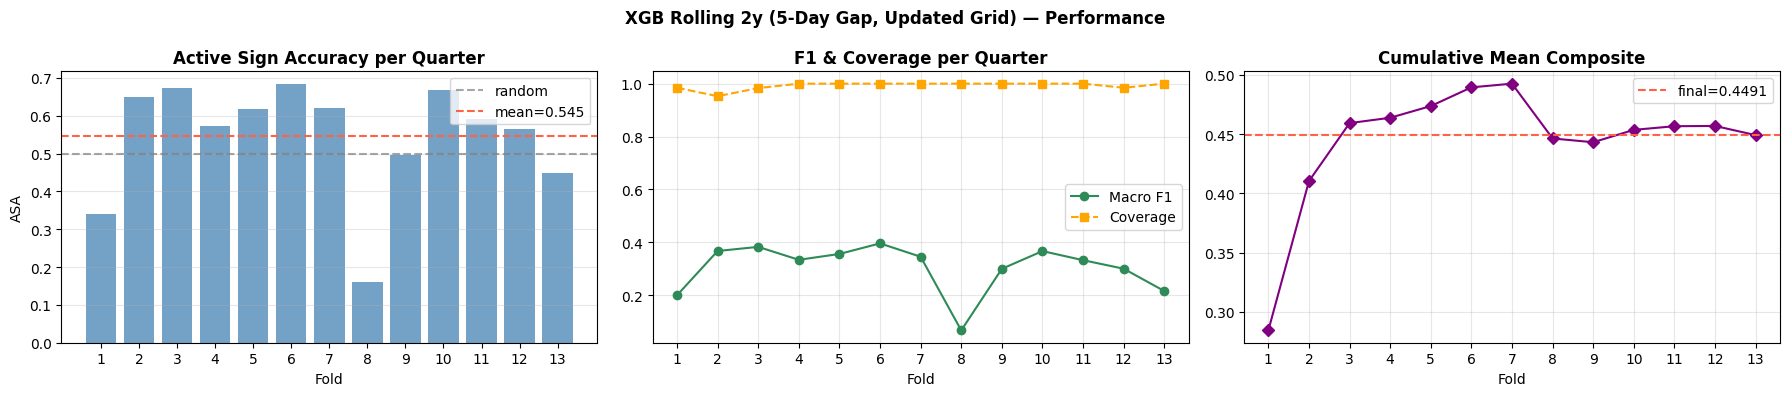

In [8]:
display_cols = ['train_rows', 'test_rows', 'mean_acc', 'macro_f1', 'active_cov', 'active_asa']

print('=== Per-Fold Performance ===')
display(results_df[display_cols].round(3))

means = results_df[display_cols].mean()
composite = 0.6 * means['active_asa'] + 0.4 * means['macro_f1']
print('\n=== Aggregate ===')
print(f'  Mean accuracy   : {means["mean_acc"]:.3f}')
print(f'  Macro F1        : {means["macro_f1"]:.3f}')
print(f'  Active coverage : {means["active_cov"]:.3f}')
print(f'  Active ASA      : {means["active_asa"]:.3f}')
print(f'  Composite       : {composite:.4f}  (0.6xASA + 0.4xF1)')

results_df['DirAcc_strict']    = results_df['active_asa'] * results_df['active_cov']
results_df['DirAcc_abstain50'] = (results_df['active_asa'] * results_df['active_cov']
                                  + 0.5 * (1 - results_df['active_cov']))
print(f'  DirAcc_strict    : {results_df["DirAcc_strict"].mean():.3f}')
print(f'  DirAcc_abstain50 : {results_df["DirAcc_abstain50"].mean():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(results_df.index.astype(str), results_df['active_asa'], color='steelblue', alpha=0.75)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='random')
axes[0].axhline(means['active_asa'], color='tomato', linestyle='--',
                label=f'mean={means["active_asa"]:.3f}')
axes[0].set_title('Active Sign Accuracy per Quarter', fontweight='bold')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('ASA')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(results_df.index.astype(str), results_df['macro_f1'],
             marker='o', color='seagreen', label='Macro F1')
axes[1].plot(results_df.index.astype(str), results_df['active_cov'],
             marker='s', color='orange', linestyle='--', label='Coverage')
axes[1].set_title('F1 & Coverage per Quarter', fontweight='bold')
axes[1].set_xlabel('Fold'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Cumulative composite
cumcomp = (0.6*results_df['active_asa'] + 0.4*results_df['macro_f1']).cumsum() / \
          np.arange(1, len(results_df)+1)
axes[2].plot(results_df.index.astype(str), cumcomp, marker='D', color='purple')
axes[2].axhline(composite, color='tomato', linestyle='--', label=f'final={composite:.4f}')
axes[2].set_title('Cumulative Mean Composite', fontweight='bold')
axes[2].set_xlabel('Fold'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('XGB Rolling 2y (5-Day Gap, Updated Grid) — Performance', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. SHAP Global Importance & Fold Stability

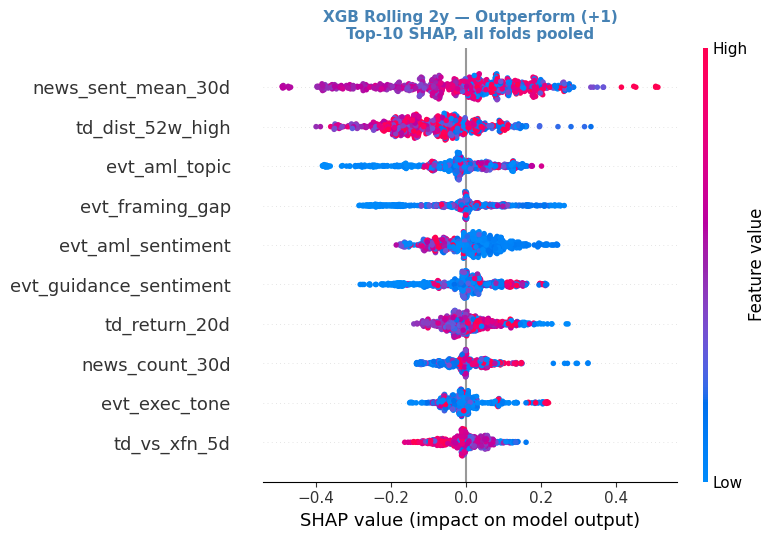

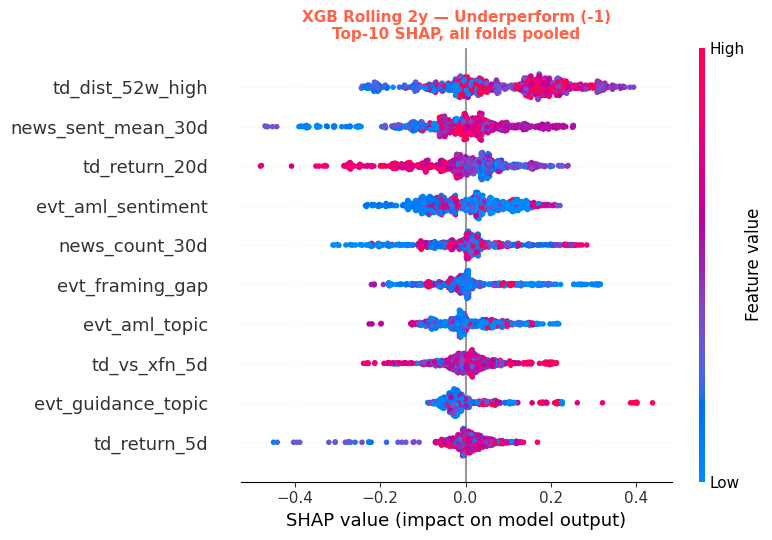

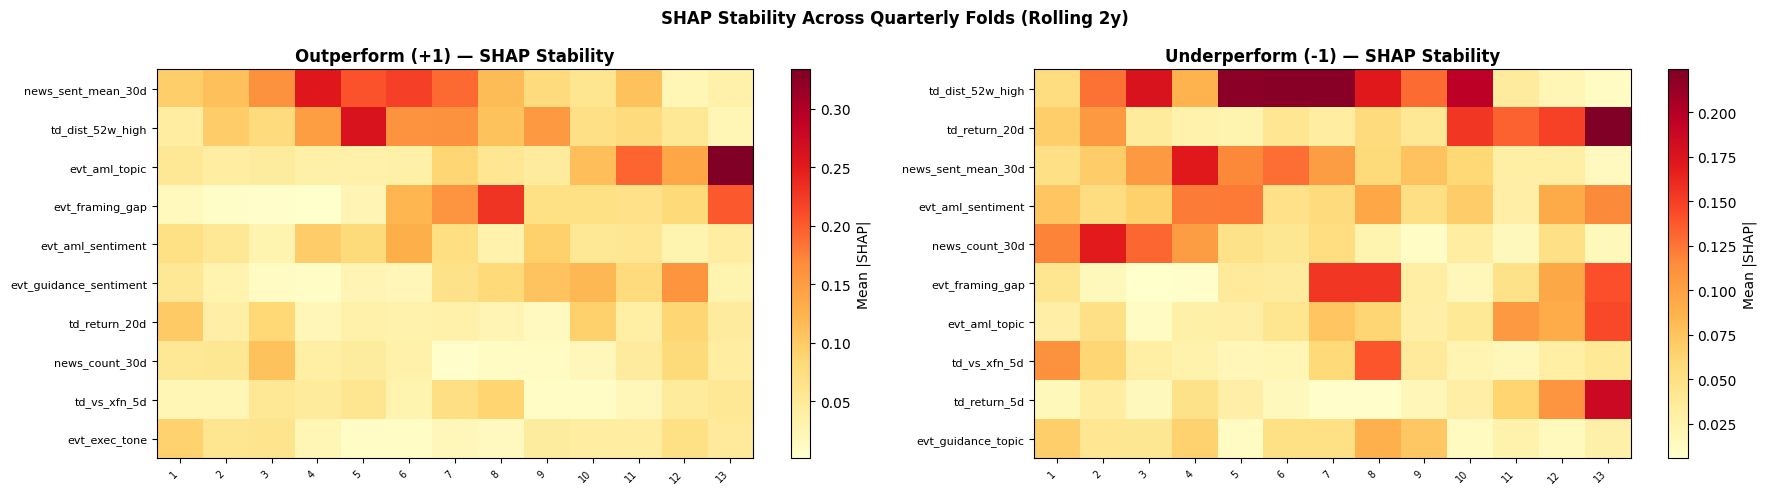

Top-10 Outperform:
news_sent_mean_30d        0.1270
td_dist_52w_high          0.1096
evt_aml_topic             0.0926
evt_framing_gap           0.0803
evt_aml_sentiment         0.0638
evt_guidance_sentiment    0.0600
td_return_20d             0.0490
news_count_30d            0.0413
td_vs_xfn_5d              0.0406
evt_exec_tone             0.0404

Top-10 Underperform:
td_dist_52w_high      0.1279
td_return_20d         0.0835
news_sent_mean_30d    0.0774
evt_aml_sentiment     0.0768
news_count_30d        0.0625
evt_framing_gap       0.0602
evt_aml_topic         0.0567
td_vs_xfn_5d          0.0468
td_return_5d          0.0444
evt_guidance_topic    0.0439


In [9]:
df_shap_out   = pd.DataFrame(fold_shap_out_dfs)
df_shap_under = pd.DataFrame(fold_shap_under_dfs)
imp_out   = df_shap_out.mean().sort_values(ascending=False)
imp_under = df_shap_under.mean().sort_values(ascending=False)

all_sv_out   = np.vstack(fold_sv_out_list)
all_sv_under = np.vstack(fold_sv_under_list)
all_x_te     = pd.concat(fold_x_te_list, ignore_index=True)

for sv_all, imp_cls, label, color in [
    (all_sv_out,   imp_out,   'Outperform (+1)',   'steelblue'),
    (all_sv_under, imp_under, 'Underperform (-1)', 'tomato'),
]:
    top10 = imp_cls.head(10).index.tolist()
    idx   = [FEATURES.index(f) for f in top10]
    plt.figure(figsize=(12, 6))
    shap.summary_plot(sv_all[:, idx], all_x_te[top10], feature_names=top10,
                      plot_type='dot', max_display=10, show=False, color_bar=True)
    plt.title(f'XGB Rolling 2y — {label}\nTop-10 SHAP, all folds pooled',
              fontsize=11, fontweight='bold', color=color)
    plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, df_cls, imp_cls, label in [
    (axes[0], df_shap_out,   imp_out,   'Outperform (+1)'),
    (axes[1], df_shap_under, imp_under, 'Underperform (-1)'),
]:
    top  = imp_cls.head(10).index.tolist()
    heat = df_cls[top].T
    im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([str(c) for c in heat.columns], rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top, fontsize=8)
    ax.set_title(f'{label} — SHAP Stability', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.suptitle('SHAP Stability Across Quarterly Folds (Rolling 2y)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('Top-10 Outperform:');  print(imp_out.head(10).round(4).to_string())
print('\nTop-10 Underperform:'); print(imp_under.head(10).round(4).to_string())

## 7. Comparison vs Previous Grid & XGB Rolling 3y

In [10]:
print('=== Updated grid (243 configs, data-aware L1/L2) ===')
means = results_df[['mean_acc','macro_f1','active_cov','active_asa']].mean()
composite_new = float(0.6 * means['active_asa'] + 0.4 * means['macro_f1'])
print(f'  acc={means["mean_acc"]:.4f}  f1={means["macro_f1"]:.4f}  '
      f'cov={means["active_cov"]:.4f}  asa={means["active_asa"]:.4f}  '
      f'composite={composite_new:.4f}')
print(f'  Best params: {BEST_PARAMS}')

print('\n=== Previous grid (27 configs, fixed L1=0.2, L2=1.0) ===')
print('  acc=0.4130  f1=0.3050  cov=0.9520  asa=0.5440  composite=0.4488')

# Compare with rolling 3y
QR3Y_DIR = NOTEBOOK_DIR.parent / 'quarterly_rolling3y/artifacts'
xgb3y_pkls = sorted(QR3Y_DIR.glob('xgb_quarterly_rolling3y-*.pkl'))
if xgb3y_pkls:
    with open(xgb3y_pkls[-1], 'rb') as f:
        art3y = pickle.load(f)
    p3y = art3y['performance_summary']
    p2y_new = {
        'mean_acc':   float(means['mean_acc']),
        'macro_f1':   float(means['macro_f1']),
        'active_cov': float(means['active_cov']),
        'active_asa': float(means['active_asa']),
        'composite':  composite_new,
    }
    cmp = pd.DataFrame({'XGB 2y (new grid)': p2y_new, 'XGB 3y': p3y})
    cmp['Delta (2y - 3y)'] = cmp['XGB 2y (new grid)'] - cmp['XGB 3y']
    print('\n=== XGB Rolling 2y (new grid) vs 3y ===')
    display(cmp.round(4))

=== Updated grid (243 configs, data-aware L1/L2) ===
  acc=0.4340  f1=0.3046  cov=0.9927  asa=0.5454  composite=0.4491
  Best params: {'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 80, 'reg_alpha': 2.0, 'reg_lambda': 10.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'}

=== Previous grid (27 configs, fixed L1=0.2, L2=1.0) ===
  acc=0.4130  f1=0.3050  cov=0.9520  asa=0.5440  composite=0.4488

=== XGB Rolling 2y (new grid) vs 3y ===


,XGB 2y (new grid),XGB 3y,Delta (2y - 3y)
mean_acc,0.4340,0.4208,0.0132
macro_f1,0.3046,0.3100,-0.0053
active_cov,0.9927,0.9573,0.0354
active_asa,0.5454,0.5436,0.0018
composite,0.4491,0.4501,-0.0010


## 8. Save Artifact

In [11]:
TODAY       = date.today().isoformat()
ARTIFACT_ID = f'xgb_quarterly_rolling2y-{TODAY}'
PKL_PATH    = ARTIFACT_DIR / f'{ARTIFACT_ID}.pkl'
JSON_PATH   = ARTIFACT_DIR / f'{ARTIFACT_ID}.json'

means     = results_df[['mean_acc','macro_f1','active_cov','active_asa']].mean()
composite = float(0.6 * means['active_asa'] + 0.4 * means['macro_f1'])

artifact = {
    'features':           FEATURES,
    'target':             TARGET,
    'threshold':          THRESHOLD,
    'label_map':          LABEL_MAP,
    'inverse_label_map':  INV_MAP,
    'best_params':        BEST_PARAMS,
    'window_type':        'rolling_2y_quarterly',
    'train_window_days':  TRAIN_WINDOW_DAYS,
    'gap_days':           GAP_DAYS,
    'grid_size':          len(param_combos),
    'n_folds_evaluated':  len(results_df),
    'performance_summary': {
        'mean_acc':   float(means['mean_acc']),
        'macro_f1':   float(means['macro_f1']),
        'active_cov': float(means['active_cov']),
        'active_asa': float(means['active_asa']),
        'composite':  composite,
    },
}
with open(PKL_PATH, 'wb') as f:
    pickle.dump(artifact, f)

meta = {
    'artifact_id':        ARTIFACT_ID,
    'model_name':         'xgb_quarterly_rolling2y',
    'window_type':        'rolling_2y_quarterly',
    'train_window_days':  TRAIN_WINDOW_DAYS,
    'gap_days':           GAP_DAYS,
    'grid_size':          len(param_combos),
    'created':            TODAY,
    'best_params':        BEST_PARAMS,
    'features':           FEATURES,
    'target':             TARGET,
    'threshold':          THRESHOLD,
    'n_folds_evaluated':  int(len(results_df)),
    'performance_summary': artifact['performance_summary'],
}
with open(JSON_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved: {PKL_PATH.name}')
print(f'Composite  : {composite:.4f}')
print(f'Best params: {BEST_PARAMS}')
print(f'Gap applied: {GAP_DAYS} trading days')
print(f'Grid size  : {len(param_combos)} configs')

Saved: xgb_quarterly_rolling2y-2026-04-23.pkl
Composite  : 0.4491
Best params: {'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 80, 'reg_alpha': 2.0, 'reg_lambda': 10.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'}
Gap applied: 5 trading days
Grid size  : 243 configs
